# (노트) 회귀분석의 다양한 풀이 (tensorflow)

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [파이썬]

In [393]:
!conda install -c conda-forge python-graphviz -y

Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 4.10.1
  latest version: 4.12.0

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/cgb3/anaconda3/envs/py310

  added / updated specs:
    - python-graphviz


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    cairo-1.16.0               |    ha12eb4b_1010         1.5 MB  conda-forge
    certifi-2021.10.8          |  py310hff52083_2         145 KB  conda-forge
    harfbuzz-4.2.0             |       h40b6f09_0         2.0 MB  conda-forge
    libgd-2.3.3                |       h283352f_2         272 KB  conda-forge
    libxml2-2.9.12             |       h885dcf4_1         760 KB  conda-forge
    python-3.10.4              |h9a8a25e_0_cpython        28.7 MB  conda-forge
    -----------------------------------------------

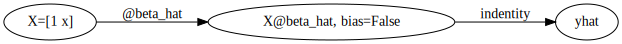

In [403]:
gv('''
"x" -> "x@beta_hat, bias=False"[label="@beta_hat"] ;
"X@beta_hat, bias=False" -> "yhat"[label="indentity"] ''')


In [6]:
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt 

In [7]:
import tensorflow.experimental.numpy as tnp 

In [8]:
tnp.experimental_enable_numpy_behavior() 

### 회귀분석 문제

`-` ${\bf y} \approx 4 + 2.5 {\bf x}$

In [162]:
tnp.random.seed(43052)
N = 200
x = tnp.linspace(0,1,N) 
epsilon = tnp.random.randn(N)*0.5
y = 2.5+4*x + epsilon
y_true = 2.5+4*x

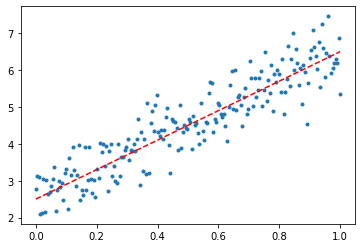

In [163]:
plt.plot(x,y,'.')
plt.plot(x,y_true,'r--')

### 이론적 풀이

#### 풀이1: 스칼라버전

`-` 포인트 
- $S_{xx}=$, $S_{xy}=$
- $\hat{\beta}_0=$, $\hat{\beta}_1=$

In [164]:
x.shape,y.shape

(TensorShape([200]), TensorShape([200]))

In [165]:
Sxx=sum((x-x.mean())**2)
Sxy=sum((x-x.mean())*(y-y.mean()))

In [166]:
beta1_hat = Sxy/Sxx
beta0_hat = y.mean() - beta1_hat *x.mean()

In [167]:
beta0_hat, beta1_hat

(<tf.Tensor: shape=(), dtype=float64, numpy=2.583667211565867>,
 <tf.Tensor: shape=(), dtype=float64, numpy=3.933034516733168>)

#### 풀이2: 벡터버전

`-` 포인트
- $\hat{\beta}=(X'X)^{-1}X'y$

In [168]:
X=tf.stack([tf.ones(N,dtype='float64'),x],axis=1)
y=y.reshape(N,1) 

In [169]:
X.shape,y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [170]:
tf.linalg.inv(X.T @ X) @ X.T @ y

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[2.58366721],
       [3.93303452]])>

#### 풀이3: 벡터버전, 손실함수의 도함수이용 

`-` 포인트
- $loss'(\beta)=-2X'y +2X'X\beta$
- $\beta_{new} = \beta_{old} - \alpha \times loss'(\beta_{old})$

In [171]:
y=y.reshape(N,1)
X.shape,y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [172]:
beta_hat = tnp.array([-5,10]).reshape(2,1)
beta_hat

<tf.Tensor: shape=(2, 1), dtype=int64, numpy=
array([[-5],
       [10]])>

In [173]:
alpha=0.1

$loss'(\beta) = -2X'y+2X'X\beta$

In [174]:
slope = -2*X.T @ y + 2*X.T@ X @ beta_hat 
slope

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[-1820.07378797],
       [ -705.77222696]])>

In [175]:
step = - alpha*slope
step 

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[182.0073788],
       [ 70.5772227]])>

In [23]:
for epoc in range(1000):
    slope = (-2*X.T @ y + 2*X.T@ X @ beta_hat)/N
    step = - alpha * slope
    beta_hat = beta_hat + step 

In [24]:
beta_hat

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[2.58366061],
       [3.93304684]])>

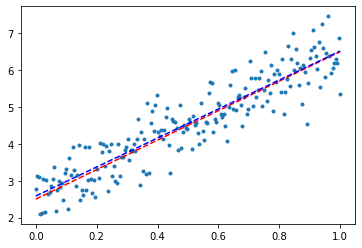

In [25]:
plt.plot(x,y,'.') 
plt.plot(x,y_true,'r--')
plt.plot(x,X@beta_hat,'b--')

---

### GradientTape를 이용 

#### 풀이1: 벡터버전

`-` 포인트
```python
## 포인트코드1: 그레디언트 테입  
with tf.GradientTape() as tape: 
    loss = 
## 포인트코드2: 미분 
slope = tape.gradient(loss,beta_hat) 
## 포인트코드3: update 
beta_hat.assign_sub(slope*alph) 
```

In [26]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [27]:
alpha=0.1

In [28]:
beta_hat = tf.Variable(tnp.array([-5.0,10.0]).reshape(2,1))
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[-5.],
       [10.]])>

In [29]:
for epoc in range(1000):
    with tf.GradientTape() as tape: 
        tape.watch(beta_hat) 
        yhat = X@beta_hat
        loss = (y-yhat).T @ (y-yhat) / N
    slope = tape.gradient(loss,beta_hat)
    beta_hat.assign_sub(slope*alpha)

In [30]:
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[2.58366061],
       [3.93304684]])>

#### 풀이2: 스칼라버전

`-` 포인트
```python
## 포인트코드: 미분
slope0,slope1 = tape.gradient(loss,[beta0_hat,beta1_hat])
```

In [31]:
y=y.reshape(-1)
x.shape, y.shape

(TensorShape([200]), TensorShape([200]))

In [32]:
alpha=0.1

In [33]:
beta0_hat = tf.Variable(-5.0)
beta1_hat = tf.Variable(10.0)

In [34]:
for epoc in range(1000):
    with tf.GradientTape() as tape: 
        yhat = beta0_hat + beta1_hat*x 
        loss = tf.reduce_sum((y-yhat)**2)/N
    slope0,slope1 = tape.gradient(loss,[beta0_hat,beta1_hat])
    beta0_hat.assign_sub(alpha*slope0) 
    beta1_hat.assign_sub(alpha*slope1) 

In [35]:
beta0_hat,beta1_hat

(<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=2.58366>,
 <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=3.933048>)

### GradientTape + opt.apply_gradients

#### 풀이1: 벡터버전 

`-` 포인트 
```python
## 포인트코드: 업데이트
opt.apply_gradients([(slope,beta_hat)])  ## pair의 list가 입력 
```

In [36]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [37]:
alpha=0.1

In [38]:
beta_hat = tf.Variable(tnp.array([-5.0,10.0]).reshape(2,1))
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[-5.],
       [10.]])>

In [41]:
opt = tf.optimizers.SGD(alpha)

In [42]:
for epoc in range(1000):
    with tf.GradientTape() as tape: 
        tape.watch(beta_hat) 
        yhat = X@beta_hat
        loss = (y-yhat).T @ (y-yhat) / N
    slope = tape.gradient(loss,beta_hat)
    opt.apply_gradients([(slope,beta_hat)])

In [43]:
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[2.58366061],
       [3.93304684]])>

#### 풀이2: 스칼라버전 

`-` 포인트
```python
## 포인트코드: 업데이트 
opt.apply_gradients([(slope0,beta0_hat),(slope1,beta1_hat)]) ## pair의 list가 입력 
```

In [44]:
y=y.reshape(-1)
x.shape, y.shape

(TensorShape([200]), TensorShape([200]))

In [45]:
alpha=0.1

In [46]:
beta0_hat= tf.Variable(-5.0)
beta1_hat= tf.Variable(10.0) 

In [47]:
opt = tf.optimizers.SGD(alpha)

In [49]:
for epoc in range(1000):
    with tf.GradientTape(persistent=True) as tape: 
        tape.watch(beta_hat) 
        yhat = beta0_hat + beta1_hat*x 
        loss = tf.reduce_sum((y-yhat)**2)/N # loss = sum((y-yhat)**2) 
    slope0 = tape.gradient(loss,beta0_hat)
    slope1 = tape.gradient(loss,beta1_hat)
    opt.apply_gradients([(slope0,beta0_hat),(slope1,beta1_hat)])

In [50]:
beta0_hat,beta1_hat

(<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=2.58366>,
 <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=3.933048>)

---

### opt.minimize

#### 풀이1: 벡터버전, 사용자정의 손실함수 with lambda

`-` 포인트
```python
## 포인트코드1: 손실함수 정의 
loss_fn = lambda: ??

## 포인트코드2: 옵티마이저 생성 
opt = tf.optimizers.SGD(alpha)

## 포인트코드3: 미분 & 업데이트 = minimize 
opt.minimize(loss_fn,beta_hat)
```

In [51]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [52]:
alpha=0.1

In [53]:
beta_hat = tf.Variable(tnp.array([-5.0,10.0]).reshape(2,1))
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[-5.],
       [10.]])>

In [54]:
loss_fn = lambda: (y-X@beta_hat).T@ (y-X@beta_hat) / N

- `lambda x : x^2 ` <=> `lambda(x)=x^2` 이라고 생각하면 편하다. 즉 함수이름이 람다라고 생각하면 편함 
- `lambda x,y : x+y ` <=> `lambda(x,y)=x+y` 
- `lambda : y ` <=> `lambda()=y`, 입력은 없고 출력은 항상 y인 함수 

In [55]:
opt = tf.optimizers.SGD(alpha)

In [57]:
for epoc in range(1000):
    opt.minimize(loss_fn,beta_hat)

In [58]:
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[2.58366061],
       [3.93304684]])>

#### 풀이2: 스칼라버전, 사용자정의 손실함수 with lambda

`-` 포인트
```python
## 포인트코드: 미분 & 업데이트 = minimize 
opt.minimize(loss_fn,[beta0_hat,beta1_hat])
```

In [60]:
y=y.reshape(-1)
x.shape, y.shape

(TensorShape([200]), TensorShape([200]))

In [61]:
alpha=0.1

In [62]:
beta0_hat = tf.Variable([-5.0])
beta1_hat = tf.Variable([10.0])

In [63]:
loss_fn = lambda: tf.reduce_sum((y-beta0_hat - beta1_hat*x)**2)/N

In [64]:
opt = tf.optimizers.SGD(alpha)

In [65]:
for epoc in range(1000):
    opt.minimize(loss_fn,[beta0_hat,beta1_hat])

In [66]:
beta0_hat,beta1_hat

(<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([2.58366], dtype=float32)>,
 <tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([3.933048], dtype=float32)>)

#### 풀이3: 벡터버전, 사용자정의 (짧은) 손실함수 

`-` 포인트
```python
## 포인트코드: 손실함수정의 
def loss_fn():
    return ??
```

In [363]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [364]:
alpha=0.1

In [365]:
beta_hat = tf.Variable(tnp.array([-5.0,10.0]).reshape(2,1))
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[-5.],
       [10.]])>

In [366]:
def loss_fn():
    return (y-X@beta_hat).T@ (y-X@beta_hat) / N 

In [367]:
opt = tf.optimizers.SGD(alpha)

In [368]:
for epoc in range(1000):
    opt.minimize(loss_fn,beta_hat)

In [369]:
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[2.58366061],
       [3.93304684]])>

#### 풀이4: 벡터버전, 사용자정의 (긴) 손실함수 

`-` 포인트
```python
## 포인트코드: 손실함수정의 
def loss_fn():
    ??
    ??
    return ??
```

In [83]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [84]:
alpha=0.1

In [85]:
beta_hat = tf.Variable(tnp.array([-5.0,10.0]).reshape(2,1))
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[-5.],
       [10.]])>

In [86]:
def loss_fn():
    yhat= X@beta_hat ## <- tape에 전달할 공식들  
    loss = (y-yhat).T@ (y-yhat) / N ## <- tape에 전달할 공식들
    return loss ## <- 미분당하는 함수 

In [87]:
opt = tf.optimizers.SGD(alpha)

In [88]:
for epoc in range(1000):
    opt.minimize(loss_fn,beta_hat)

In [89]:
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[2.58366061],
       [3.93304684]])>

#### 풀이5: 벡터버전, 사용자정의 손실함수 <- tf.losses.MSE 

`-` 포인트
```python
## 포인트코드: 미리구현되어있는 손실함수 이용 
tf.losses.MSE(y,yhat)
```

In [90]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [91]:
alpha=0.1

In [92]:
beta_hat = tf.Variable(tnp.array([-5.0,10.0]).reshape(2,1))
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[-5.],
       [10.]])>

In [93]:
def loss_fn():
    yhat= X@beta_hat
    loss = tf.losses.MSE(y.reshape(-1),yhat.reshape(-1))
    return loss 

In [94]:
opt = tf.optimizers.SGD(alpha)

In [95]:
for epoc in range(1000):
    opt.minimize(loss_fn,beta_hat)

In [96]:
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[2.58366061],
       [3.93304684]])>

#### 풀이6: 벡터버전, 사용자정의 손실함수 <- tf.losses.MeaSquaredError

`-` 포인트
```python
## 포인트코드: 클래스로부터 손실함수 오브젝트 생성 (함수를 찍어내는 클래스) 
mse_fn = tf.losses.MeanSquaredError()
mse_fn(y,yhat)
```

In [97]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [98]:
alpha=0.1

In [99]:
beta_hat = tf.Variable(tnp.array([-5.0,10.0]).reshape(2,1))
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[-5.],
       [10.]])>

In [100]:
mse_fn = tf.losses.MeanSquaredError()

In [101]:
def loss_fn():
    yhat= X@beta_hat
    loss = mse_fn(y.reshape(-1),yhat.reshape(-1))
    return loss 

In [102]:
opt = tf.optimizers.SGD(alpha)

In [103]:
for epoc in range(1000):
    opt.minimize(loss_fn,beta_hat)

In [105]:
beta_hat

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[2.58366061],
       [3.93304684]])>

### tf.keras.Sequential

`-` $\hat{y}_i=\hat{\beta}_0+\hat{\beta}_1x_i$ 의 서로다른 표현 

In [3]:
import graphviz
def gv(s): return graphviz.Source('digraph G{ rankdir="LR"'+s + '; }')

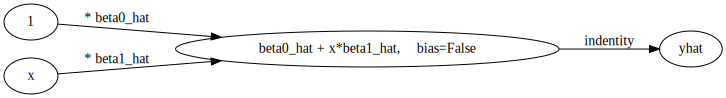

In [4]:
gv(''' 
    "1" -> "beta0_hat + x*beta1_hat,    bias=False"[label="* beta0_hat"]
    "x" -> "beta0_hat + x*beta1_hat,    bias=False"[label="* beta1_hat"]
    "beta0_hat + x*beta1_hat,    bias=False" -> "yhat"[label="indentity"]
    ''')

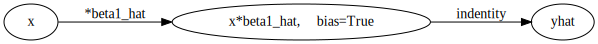

In [5]:
gv('''
"x" -> "x*beta1_hat,    bias=True"[label="*beta1_hat"] ;
"x*beta1_hat,    bias=True" -> "yhat"[label="indentity"] ''')


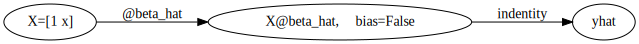

In [6]:
gv('''
"X=[1 x]" -> "X@beta_hat,    bias=False"[label="@beta_hat"] ;
"X@beta_hat,    bias=False" -> "yhat"[label="indentity"] ''')


#### 풀이1: 벡터버전, 사용자정의 손실함수 

`-` 포인트
```python
## 포인트코드1: 네트워크 생성 
net = tf.keras.Sequential()

## 포인트코드2: 네트워크의 아키텍처 설계 
net.add(tf.keras.layers.Dense(1,input_shape=(2,),use_bias=False)) 

## 포인트코드3: 네트워크 컴파일 = 아키텍처 + 손실함수 + 옵티마이저
net.compile(opt,loss=loss_fn2)

## 포인트코드4: 미분 & update 
net.fit(X,y,epochs=1000,verbose=0,batch_size=N) 
```

In [117]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [118]:
alpha=0.1

In [119]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1,input_shape=(2,),use_bias=False)) 

In [120]:
def loss_fn2(y,yhat):
    loss = (y-yhat).T @ (y-yhat) / N
    return loss 

In [121]:
opt = tf.keras.optimizers.SGD(alpha)

In [122]:
net.compile(opt,loss=loss_fn2)

In [123]:
net.get_weights()

[array([[ 0.6924859],
        [-0.3262385]], dtype=float32)]

In [124]:
net.set_weights([np.array([-5.0,10.0]).reshape(2,1)])

In [125]:
net.fit(X,y,epochs=1000,verbose=0,batch_size=N)

In [126]:
net.get_weights()

[array([[2.58366 ],
        [3.933048]], dtype=float32)]

#### 풀이2: 벡터버전, net.compile의 옵션으로 손실함수 지정 

`-` 포인트
```python
## 포인트코드: 네트워크 컴파일 = 아키텍처 + 손실함수 + 옵티마이저
net.compile(opt,loss='mse') # net.compile의 옵션으로 손실함수 지정 
```

In [116]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [129]:
alpha=0.1

In [130]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1,input_shape=(2,),use_bias=False)) 

In [131]:
opt = tf.keras.optimizers.SGD(alpha)

In [132]:
net.compile(opt,loss='mse')

In [133]:
net.get_weights()

[array([[ 0.98623264],
        [-0.4947716 ]], dtype=float32)]

In [134]:
net.set_weights([np.array([-5.0,10.0]).reshape(2,1)])

In [135]:
net.fit(X,y,epochs=1000,verbose=0,batch_size=N)

In [136]:
net.get_weights()

[array([[2.58366 ],
        [3.933048]], dtype=float32)]

#### 풀이3: 스칼라버전, net.compile의 옵션으로 손실함수 지정 

`-` 포인트
```python
## 포인트코드: use_bias=True
net.add(tf.keras.layers.Dense(1,input_shape=(1,),use_bias=True)) 
```

In [239]:
y=y.reshape(-1)
x.shape, y.shape

(TensorShape([200]), TensorShape([200]))

In [240]:
alpha=0.1

In [241]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1,input_shape=(1,),use_bias=True)) 

In [242]:
opt = tf.keras.optimizers.SGD(alpha)

In [243]:
net.compile(opt,loss='mse')

In [244]:
net.get_weights()

[array([[-1.1765249]], dtype=float32), array([0.], dtype=float32)]

- [weight,bias] 순으로 출력

In [245]:
net.set_weights([np.array([[10.0]]),np.array([-5.0])])

In [246]:
net.get_weights()

[array([[10.]], dtype=float32), array([-5.], dtype=float32)]

In [247]:
net.fit(x,y,epochs=1000,verbose=0,batch_size=N)

In [248]:
net.get_weights()

[array([[3.933048]], dtype=float32), array([2.58366], dtype=float32)]

### tf.keras.Model

#### 풀이1: 벡터버전

`-` 포인트 
```python
## 포인트코드: 네트워크 설계 (Xi -> yihat의 과정을 공책에 쭉 쓰는 느낌)
Xi = tf.keras.layers.Input(shape=(2,)) 
l1 = tf.keras.layers.Dense(units=1,input_shape=(2,),use_bias=False) 
yihat = l1(Xi) 
net = tf.keras.Model(Xi,yihat)
```

In [372]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

In [373]:
alpha=0.1

In [374]:
Xi = tf.keras.layers.Input(shape=(2,))  # shape =  X -> yhat 에서 X의 차원 
l1 = tf.keras.layers.Dense(units=1,input_shape=(2,),use_bias=False) # units:= X -> yhat 에서 yhat의 차원 
yihat = l1(Xi) 

In [375]:
net = tf.keras.Model(Xi,yihat)

In [376]:
net.set_weights([np.array([-5.0,10.0]).reshape(2,1)])

In [377]:
alpha=0.1

In [378]:
opt = tf.keras.optimizers.SGD(alpha)

In [379]:
net.compile(opt,"mse")

In [380]:
net.fit(X,y,epochs=1000,verbose=0,batch_size=N)

In [381]:
net.weights

[<tf.Variable 'dense_44/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[2.58366 ],
        [3.933048]], dtype=float32)>]

#### 풀이2: 스칼라버전 

`-` 포인트 
```python
## 포인트코드: 네트워크 설계 (입력차원 조심, 바이어스 조심) 
xi = tf.keras.layers.Input(shape=(1,)) 
l1 = tf.keras.layers.Dense(units=1,input_shape=(1,),use_bias=True)
```

In [383]:
y=y.reshape(-1)
x.shape, y.shape

(TensorShape([200]), TensorShape([200]))

In [384]:
alpha=0.1

In [385]:
xi = tf.keras.layers.Input(shape=(1,))  
l1 = tf.keras.layers.Dense(units=1,input_shape=(1,),use_bias=True)
yihat = l1(xi) 

In [386]:
net = tf.keras.Model(xi,yihat)

In [387]:
net.set_weights([np.array([[10.0]]),np.array([-5.0])])

In [388]:
alpha=0.1

In [389]:
opt = tf.keras.optimizers.SGD(alpha)

In [390]:
net.compile(opt,"mse")

In [391]:
net.fit(x,y,epochs=1000,verbose=0,batch_size=N)

In [392]:
net.weights

[<tf.Variable 'dense_45/kernel:0' shape=(1, 1) dtype=float32, numpy=array([[3.933048]], dtype=float32)>,
 <tf.Variable 'dense_45/bias:0' shape=(1,) dtype=float32, numpy=array([2.58366], dtype=float32)>]